Install necessary libraries  
Import necessary libraries 

In [1]:
# install these
!pip install shap joblib xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline


Fetch the data

In [3]:
# loading directly from the URL
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
COLUMNS = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

df = pd.read_csv(URL, names=COLUMNS)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Conduct EDA

In [4]:
# access the number of rows and columns
df.shape

(768, 9)

In [5]:
# overview of data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# check for null values
df.isnull().sum()/len(df)

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

In [7]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
# get the number of unique values in each column
for col in df.columns:
    values = df[col].nunique()
    print(f'{col}:{values}')

Pregnancies:17
Glucose:136
BloodPressure:47
SkinThickness:51
Insulin:186
BMI:248
DiabetesPedigreeFunction:517
Age:52
Outcome:2


In [9]:
# check for outlier
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



The above depicts a case of unrealistic data entry as zero cannot be correct for some of the variables. Also, it shows that outliers
are inherent in the dataset especially looking at insulin as the std is twice the value of the mean. Clinical records usually have standardized reading ranges and as such, this dataset will be treated likewise to allow for proper feature engineering


Quick Reference Table (Simplified Clinical Cutoffs)
| Feature | Critical Low | Normal (Non-Pregnant) | Pregnancy Normal | Elevated | Danger High |
|---------|--------------|----------------------|------------------|----------|--------------|
| **Glucose** | <50 (hypoglycemia) | Fasting: 70–99 | Fasting: <92 | 100–199 | ≥200 (diabetic crisis)<br>GDM: ≥92 fasting |
| **BloodPressure (Diastolic)** | <60 (hypotension) | 60–80 | 60–80 | 81–89 | ≥90 (hypertension)<br>Pregnancy: ≥90 = preeclampsia risk |
| **SkinThickness** | <5 (malnutrition) | 10–25 | 10–25 (naturally increases) | 26–40 | >40 (severe obesity) |
| **Insulin** | <2 (Type 1 diabetes) | 2–25 | 10–35 (3rd trimester) | 26–200 | >200 (extreme resistance) |
| **BMI** | <15 (underweight) | 18.5–24.9 | Assess pre-pregnancy | 25–39.9 | ≥40 (morbid obesity) |
| **DPF** | N/A (no lower bound) | 0.2–0.4 | Same as non-pregnant | 0.4–0.8 | >0.8 (very high genetic risk) |



Visualizing the outliers before dealing with them

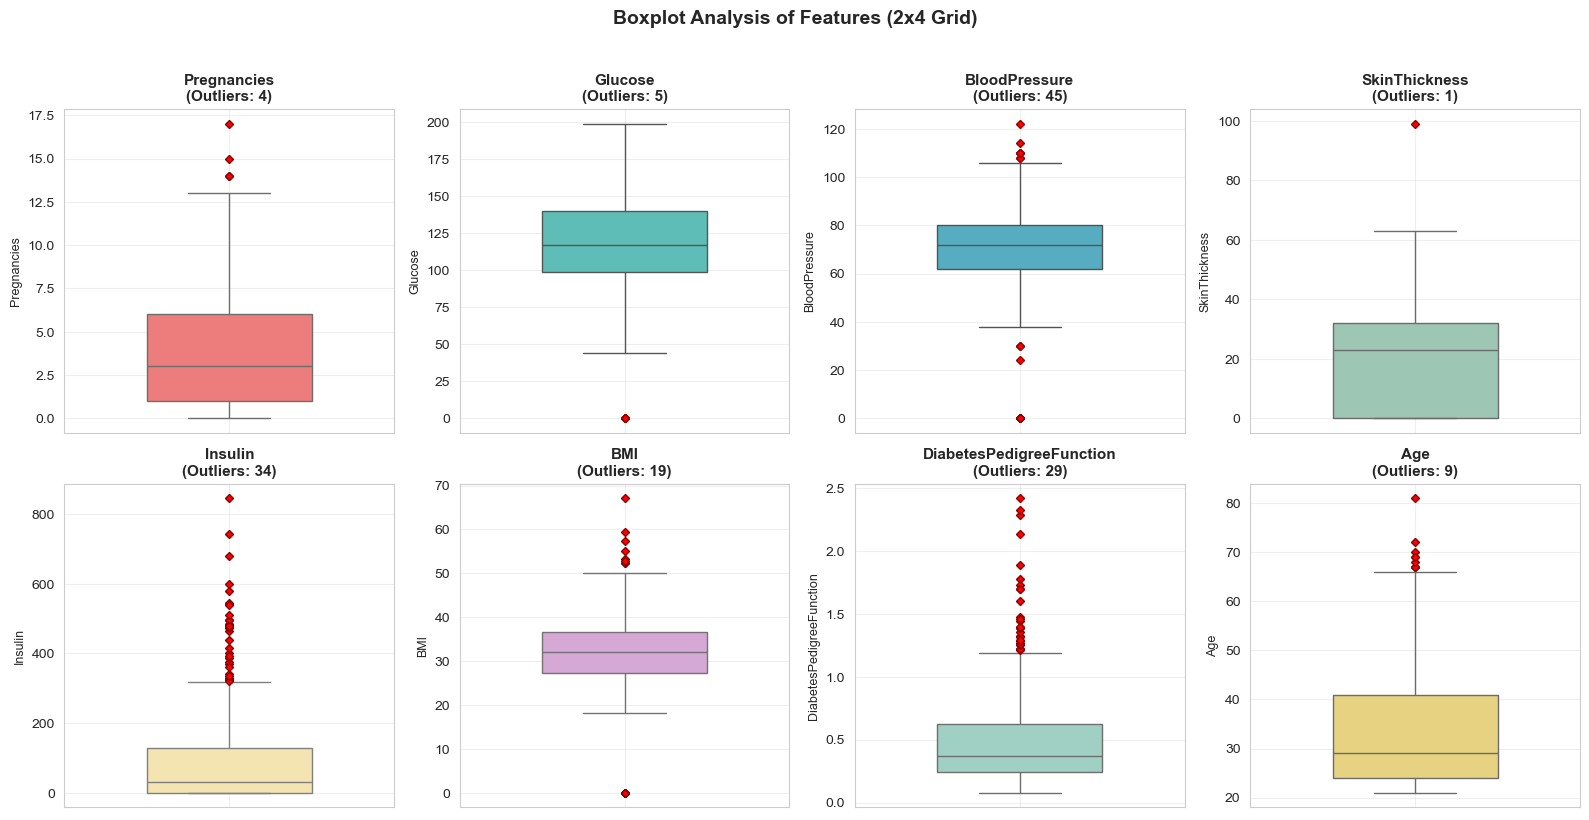

In [10]:

# Set style
sns.set_style("whitegrid")

# Create 2x4 grid
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat = axes.flatten()

# Columns to plot (excluding Outcome)
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Color palette
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', 
          '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F']

for i, col in enumerate(columns):
    # Create boxplot with custom outlier styling
    sns.boxplot(y=df[col], ax=axes_flat[i], 
                color=colors[i], 
                width=0.5,
                fliersize=4,
                flierprops={'marker': 'D', 'markerfacecolor': 'red', 
                           'markeredgecolor': 'darkred', 'markersize': 4})
    
    # Calculate and display outlier count
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])
    
    # Add title with outlier count
    axes_flat[i].set_title(f'{col}\n(Outliers: {outlier_count})', 
                          fontsize=11, fontweight='bold')
    axes_flat[i].set_ylabel(col, fontsize=9)
    axes_flat[i].grid(True, alpha=0.3)

plt.suptitle('Boxplot Analysis of Features (2x4 Grid)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

preprocess the data

The zeros in the data will be replaced with NaN  

The columns (Glucose, BloodPressure, SkinThickness, Insulin, BMI) cannot biologically be zero in a living person  

Median imputation carried out (as against mean)  

Finally, since this is a machine learning task, the outliers can be dealt with by winsorizing/capping it.

In [11]:
# Replace zeros with NaN
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)

# Then use median imputation
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df[col].fillna(df[col].median(), inplace=True)

winsorize the data using IQR

In [12]:
# Separate features and target
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# 1. Calculate Q1 and Q3
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

# 2. Calculate IQR and define the bounds
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Winsorize (Cap) the data
# Any value below the lower_bound is replaced by the lower_bound
# Any value above the upper_bound is replaced by the upper_bound
X_capped = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

# 4. Recombine
df_capped = pd.concat([X_capped, y], axis=1)
df_capped.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.837240,121.656250,72.358073,28.866536,124.691081,32.393359,0.458914,33.199870,0.348958
std,3.344157,30.438286,11.697097,7.442353,7.913595,6.667471,0.285596,11.628404,0.476951
min,0.000000,44.000000,40.000000,14.500000,112.875000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,13.500000,199.000000,104.000000,42.500000,135.875000,50.250000,1.200000,66.500000,1.000000


winsorized data can be confirmed by looking at the max values (reduced) and min values (increased) compared to the original df  

visualization after winsorizng

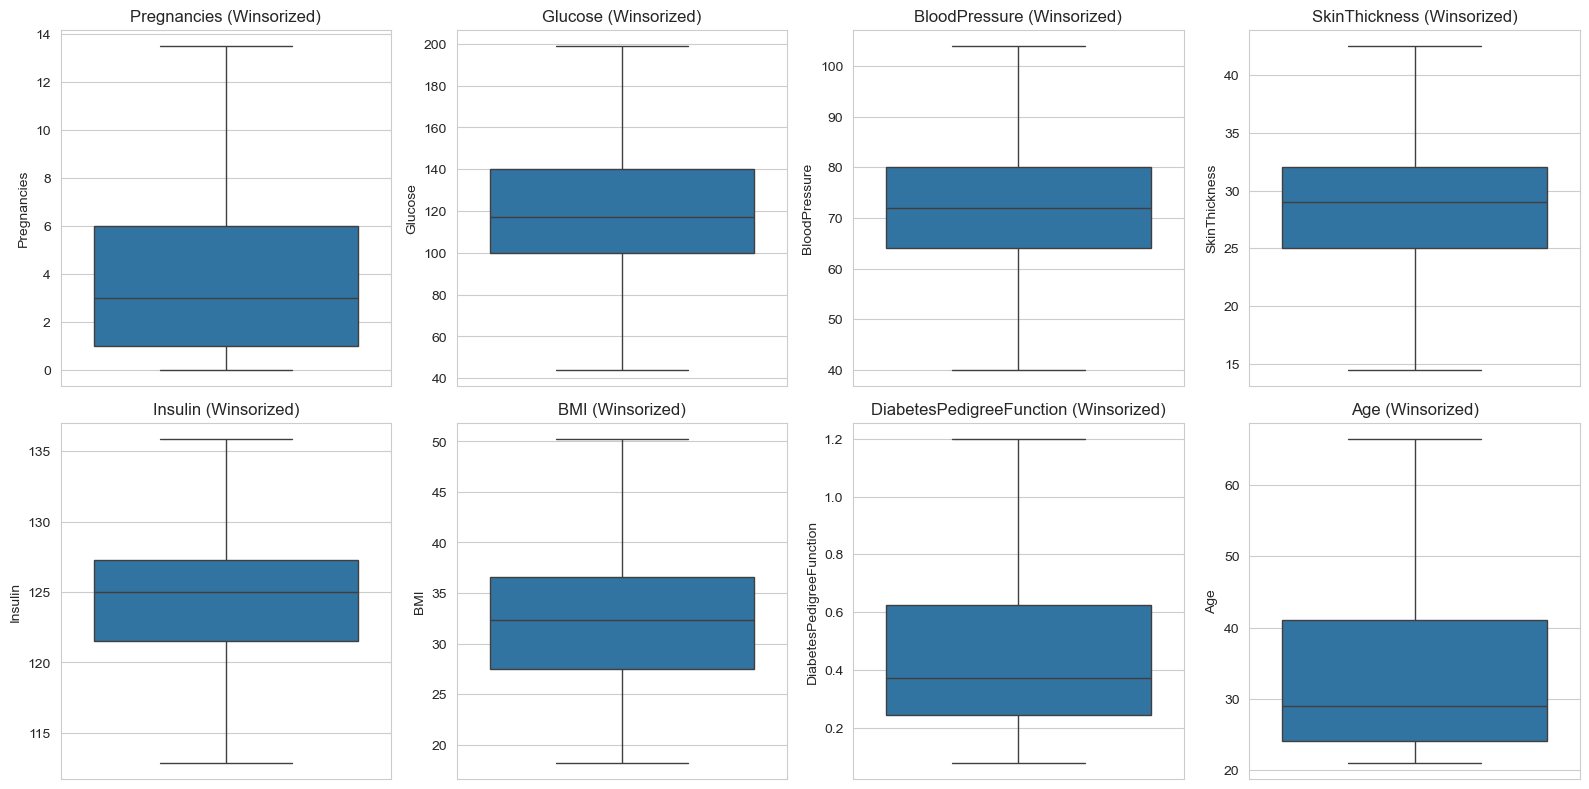

In [13]:
# Separate features (exclude target)
X = df_capped.drop(columns=["Outcome"])

# Plot 2x4 grid 
features = X.columns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df_capped[col], ax=axes[i])
    axes[i].set_title(f"{col} (Winsorized)")

plt.tight_layout()
plt.show()

Check class balances (nature of imbalance)

In [14]:
# imbalance check
df_capped['Outcome'].value_counts(normalize=True)*100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

The ratio 65:35 is mild hence no further treatemnt required

Split data  

Train, Test  

Scale features 

In [15]:
# split
X = df_capped.drop('Outcome', axis=1)
y = df_capped[['Outcome']]

In [16]:
#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [17]:
# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Build model, Cross validation

In [18]:
# base model
base_model = y_train.value_counts(normalize=True).max()
base_model

0.6514657980456026

3 ML models to be compared and best performing (in predictng diabetics) is selected:  

LogisticRegression  
RandomForestClassifier  
GradientBoostingClassifier

In [19]:
# Set random seed
random_seed = 42
np.random.seed(random_seed)

# Create list of models
models = [
    ('RandomForest', RandomForestClassifier(random_state=random_seed)),
    ('LogisticRegression', LogisticRegression(random_state=random_seed, max_iter=1000)),
    ('GradientBoosting', GradientBoostingClassifier(random_state=random_seed))
]

# Store results
results = []

# Evaluate each model
for name, model in models:
    
    # Create cross-validation strategy
    kfold = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=random_seed
    )
    
    # Perform cross-validation
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kfold,
        scoring='accuracy'
    )
    
    # Save results
    results.append((name, cv_scores.mean(), cv_scores.std()))

# Print results
for name, mean_score, std_score in results:
    print(f'{name}: Mean Accuracy = {mean_score:.4f}, Std = {std_score:.4f}')

RandomForest: Mean Accuracy = 0.7671, Std = 0.0196
LogisticRegression: Mean Accuracy = 0.7850, Std = 0.0126
GradientBoosting: Mean Accuracy = 0.7492, Std = 0.0141


Fit model

In [20]:
# Fit model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Evaluate model  

Accuracy score  

Classficatio report

In [21]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7078


In [22]:
# Classification Report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [23]:
print(confusion_matrix(y_test,y_pred))

[[82 18]
 [27 27]]


Confusion matrix chart

<Figure size 500x500 with 0 Axes>

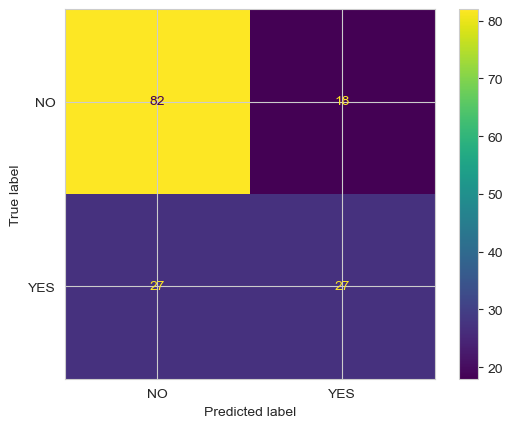

In [24]:
plt.figure(figsize=(5,5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["NO", "YES"])
disp.plot()
plt.show()

Feature importance extraction and chart

                    Feature  Importance
6  DiabetesPedigreeFunction    0.831483
0               Pregnancies    0.112380
5                       BMI    0.102232
1                   Glucose    0.036897
4                   Insulin    0.024011
7                       Age    0.013649
3             SkinThickness    0.001680
2             BloodPressure   -0.003077


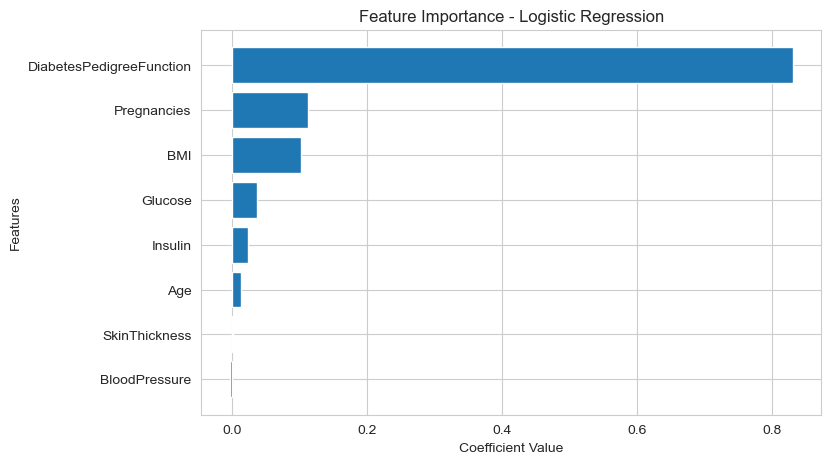

In [25]:
# Extract feature importance (coefficients)
importance = model.coef_[0]

# Create DataFrame for feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Print feature importance
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Feature Importance - Logistic Regression")

plt.gca().invert_yaxis()

plt.show()